# Food Delivery Classification Project

Domain: Data Science & Machine Learning

Sub-domain: Machine Learning

Problem Type: Classification

Application Area: Food Delivery / Restaurant Analytics

Target: Delivery Delay Status

Tools: Python, Google Colab, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

# Project Goal

The goal of this project is to analyze food delivery data to identify important patterns and trends in orders, restaurants, locations, order amounts, and delivery times, and to build a machine learning model to classify delivery delay status.

# Problem Statement
The food delivery dataset contains information about orders, customers, restaurants, locations, order amounts, and delivery times. The problem is to analyze this data to identify important patterns and factors related to delivery delays and classify orders based on their delivery delay status using machine learning.

### Objectives

1. To analyze food delivery data.
2. To find order and delivery patterns.
3. To analyze restaurants and food items.
4. To study delivery delays.
5. To create charts and graphs.
6. To classify delivery delays using machine learning.


### Future Scope

1. Analyze more food delivery data.
2. Improve the delivery delay prediction model.
3. Add more machine learning algorithms.
4. Build a real-time delivery monitoring system.
5. Develop a dashboard for easy data visualization.
6. Use customer feedback to improve delivery services.


# Libraries

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the Food Delivery CSV file
df = pd.read_csv('/content/Food Delivery dataset.csv')


In [ ]:
#Display first few records
df.head()
df.tail()

,order_id,restaurant_id,food_item,order_time,delivery_time,delivery_distance,order_value,delivery_method,traffic_condition,weather_condition,...,food_temperature,food_freshness,packaging_quality,food_condition,customer_satisfaction,small_route,bike_friendly_route,route_type,route_efficiency,traffic_avoidance
19995,ORD019996,21.0,Chicken wings,10-27-24,10-27-24,9.07,13.64,Car,Medium,Sunny,...,Cold,4,3,Poor,1,True,True,Bike-friendly,0.585074,No
19996,ORD019997,65.0,Chicken wings,12-04-24,12-04-24,5.41,16.71,Car,High,Sunny,...,Warm,1,2,Fair,1,True,True,Mixed,0.678230,No
19997,ORD019998,83.0,Shawarma,10-25-24,10-25-24,9.07,15.52,Bike,Medium,Sunny,...,Warm,4,2,Good,4,True,True,Car-only,0.560679,No
19998,ORD019999,13.0,Shawarma,10-02-24,10-02-24,13.48,16.49,Car,Medium,Snowy,...,Warm,2,3,Poor,3,False,True,Mixed,0.624297,No
19999,ORD020000,26.0,Pasta,02-14-24,02-14-24,14.23,37.31,Bike,High,Sunny,...,Warm,3,4,Good,3,False,True,Car-only,0.161206,No


In [ ]:
#Check dataset shape
df.shape

(20000, 31)

In [ ]:
# Display statistical information
df.describe()

,restaurant_id,delivery_distance,order_value,delivery_delay,age,order_history,customer_rating,food_freshness,packaging_quality,customer_satisfaction,route_efficiency
count,19600.000000,19600.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,50.503980,8.497162,27.335090,4.952421,38.925300,25.751400,3.026800,2.991700,3.003400,2.976300,0.496246
std,28.719046,3.766675,13.026475,8.624563,12.370941,14.311731,1.416468,1.415744,1.416929,1.415217,0.287044
min,1.000000,2.000000,5.000000,-10.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000276
25%,26.000000,5.230000,15.960000,-2.430000,28.000000,13.000000,2.000000,2.000000,2.000000,2.000000,0.245070
50%,50.000000,8.460000,27.200000,4.900000,39.000000,26.000000,3.000000,3.000000,3.000000,3.000000,0.494741
75%,75.000000,11.800000,38.712500,12.320000,50.000000,38.000000,4.000000,4.000000,4.000000,4.000000,0.742996
max,100.000000,15.000000,49.990000,20.000000,60.000000,50.000000,5.000000,5.000000,5.000000,5.000000,0.999841


In [ ]:
df.dtypes

,0
order_id,object
restaurant_id,float64
food_item,object
order_time,object
delivery_time,object
delivery_distance,float64
order_value,float64
delivery_method,object
traffic_condition,object
weather_condition,object


# Missing values

In [ ]:
#Check missing values
df.isnull().sum()

,0
order_id,400
restaurant_id,400
food_item,400
order_time,400
delivery_time,400
delivery_distance,400
order_value,0
delivery_method,0
traffic_condition,0
weather_condition,0


# Duplicate values

In [ ]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Remove duplicate values
df = df.drop_duplicates()

In [ ]:
# Check again
df.duplicated().sum()

np.int64(0)

# Handle missing values

In [ ]:
# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Check Unknown values in each column
for col in df.columns:
    print(col, ":", (df[col].astype(str).str.lower() == 'unknown').sum())

order_id : 0
restaurant_id : 0
food_item : 0
order_time : 0
delivery_time : 0
delivery_distance : 0
order_value : 0
delivery_method : 0
traffic_condition : 0
weather_condition : 0
delivery_delay : 0
route_taken : 0
customer_id : 0
age : 0
gender : 0
location : 0
order_history : 0
customer_rating : 0
preferred_cuisine : 0
order_frequency : 0
loyalty_program : 0
food_temperature : 0
food_freshness : 0
packaging_quality : 0
food_condition : 0
customer_satisfaction : 0
small_route : 0
bike_friendly_route : 0
route_type : 0
route_efficiency : 0
traffic_avoidance : 0


# Convert Data Types


In [ ]:
df['delivery_distance'] = pd.to_numeric(df['delivery_distance'], errors='coerce')
df['order_value'] = pd.to_numeric(df['order_value'], errors='coerce')
df['delivery_delay'] = pd.to_numeric(df['delivery_delay'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['customer_rating'] = pd.to_numeric(df['customer_rating'], errors='coerce')
df['customer_satisfaction'] = pd.to_numeric(df['customer_satisfaction'], errors='coerce')

df['order_time'] = pd.to_datetime(df['order_time'], errors='coerce')
df['delivery_time'] = pd.to_datetime(df['delivery_time'], errors='coerce')

print(df.dtypes)

order_id                         object
restaurant_id                   float64
food_item                        object
order_time               datetime64[ns]
delivery_time            datetime64[ns]
delivery_distance               float64
order_value                     float64
delivery_method                  object
traffic_condition                object
weather_condition                object
delivery_delay                  float64
route_taken                      object
customer_id                      object
age                               int64
gender                           object
location                         object
order_history                     int64
customer_rating                   int64
preferred_cuisine                object
order_frequency                  object
loyalty_program                  object
food_temperature                 object
food_freshness                    int64
packaging_quality                 int64
food_condition                   object


/tmp/ipykernel_1275/1172249323.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'], errors='coerce')
/tmp/ipykernel_1275/1172249323.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_time'] = pd.to_datetime(df['delivery_time'], errors='coerce')


In [ ]:
print("Missing order_time:", df['order_time'].isnull().sum())
print("Missing delivery_time:", df['delivery_time'].isnull().sum())

Missing order_time: 0
Missing delivery_time: 0


In [ ]:
#Analyze most ordered food items
df['food_item'].value_counts().head(10)

,count
food_item,
Pasta,2242
Whole cake,943
Cup cake,929
Soup,927
Chicken rice,917
Cookie,912
Beef pie,912
Chicken wings,909
CoffeeBoba tea,899


In [ ]:
#Analyze popular restaurants
df['restaurant_id'].value_counts().head(10)

,count
restaurant_id,
50.0,603
43.0,241
42.0,236
40.0,235
75.0,231
10.0,230
95.0,230
38.0,227
19.0,225


In [ ]:
#Analyze orders by location
df['location'].value_counts()

,count
location,
Ahmedabad,2051
Kolkata,2032
Delhi,2027
Pune,2026
Jaipur,2013
Chennai,1998
Mumbai,1980
Hyderabad,1973
Bangalore,1968


In [ ]:
#Analyze delivery time
df['delivery_time'].head(5)

,delivery_time
0,2024-01-31
1,2024-10-16
2,2024-09-11
3,2024-09-17
4,2024-08-26


In [ ]:
df['order_value'].mean()

np.float64(27.33509)

In [ ]:
df['delivery_delay'].mean()

np.float64(4.952421)

In [ ]:
# Remove rows containing missing values
df = df.dropna()

#Feature Engineering



In [ ]:

# Delivery efficiency
df['delivery_efficiency'] = (
    df['delivery_distance'] / (df['delivery_delay'].abs() + 1)
)

# Order value per distance
df['value_per_distance'] = (
    df['order_value'] / (df['delivery_distance'] + 1)
)

# Age group
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']
)

# High value order
df['high_value_order'] = df['order_value'].apply(
    lambda x: 'Yes' if x > df['order_value'].median() else 'No'
)

# Check new columns
print(df[['delivery_efficiency',
          'value_per_distance',
          'age_group',
          'high_value_order']].head())

   delivery_efficiency  value_per_distance    age_group high_value_order
0             0.119559           13.315457        Adult              Yes
1             0.786385            1.723611   Middle Age               No
2             1.064420            3.172913  Young Adult              Yes
3             2.022508            6.842250        Adult              Yes
4             0.222727            2.164975  Young Adult               No


# EDA preparation

#Univariate Analysis

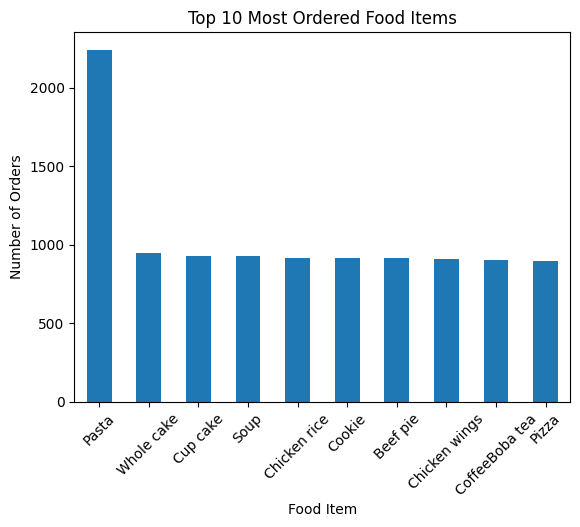

In [ ]:
#Top 10 Most Ordered Food Items
df['food_item'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Most Ordered Food Items')
plt.xlabel('Food Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

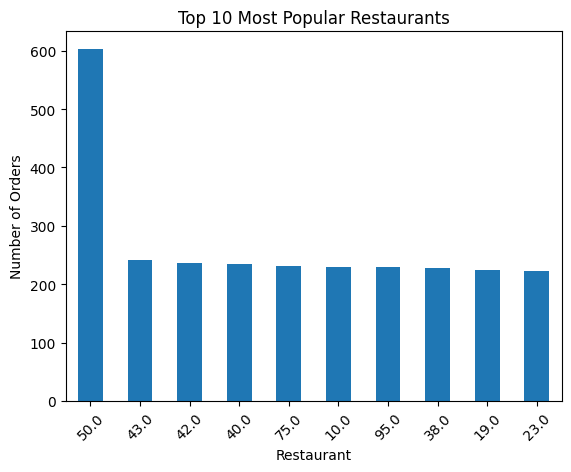

In [ ]:
#Top 10 Most Popular Restaurants
df['restaurant_id'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Most Popular Restaurants')
plt.xlabel('Restaurant')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

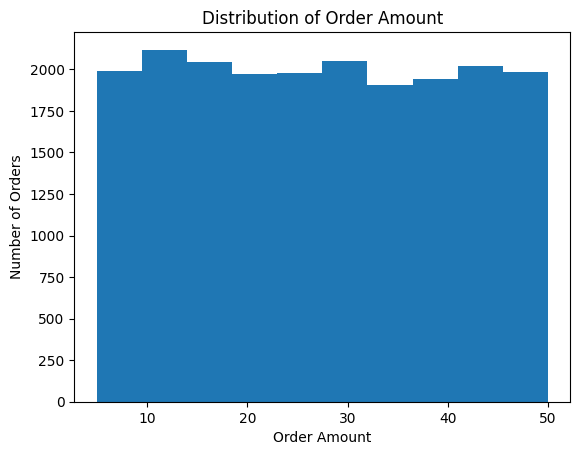

In [ ]:
#Distribution of Order Amount
df['order_value'].plot(kind='hist', bins=10)

plt.title('Distribution of Order Amount')
plt.xlabel('Order Amount')
plt.ylabel('Number of Orders')
plt.show()

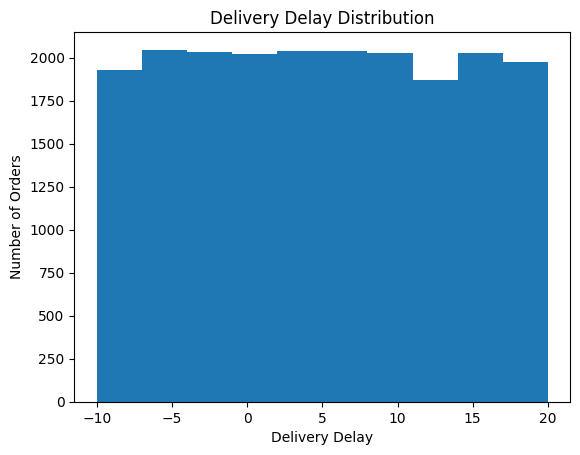

In [ ]:
#Delivery Delay Distribution
df['delivery_delay'].plot(kind='hist', bins=10)
plt.title('Delivery Delay Distribution')
plt.xlabel('Delivery Delay')
plt.ylabel('Number of Orders')
plt.show()

# Bivariate Analysis

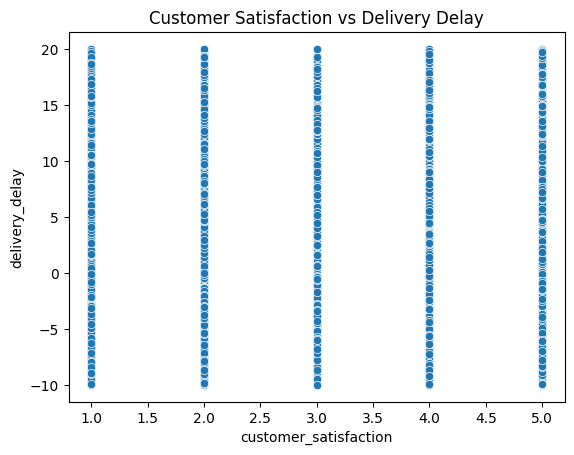

In [ ]:
#Customer Satisfaction vs Delivery Delay
sns.scatterplot(
    x='customer_satisfaction',
    y='delivery_delay',
    data=df
)

plt.title('Customer Satisfaction vs Delivery Delay')
plt.show()

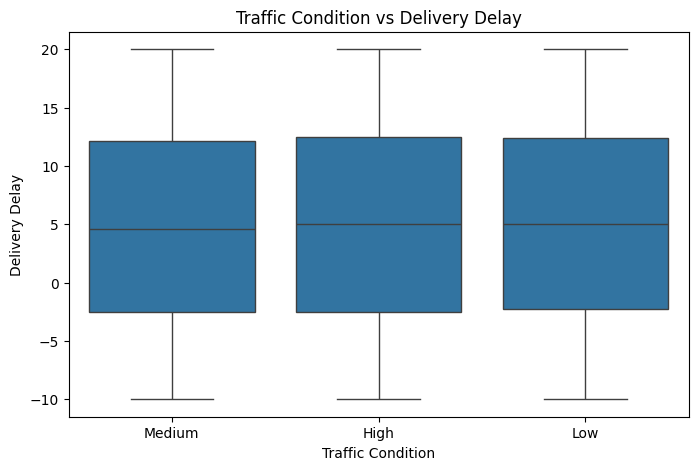

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='traffic_condition', y='delivery_delay', data=df)

plt.title('Traffic Condition vs Delivery Delay')
plt.xlabel('Traffic Condition')
plt.ylabel('Delivery Delay')
plt.show()

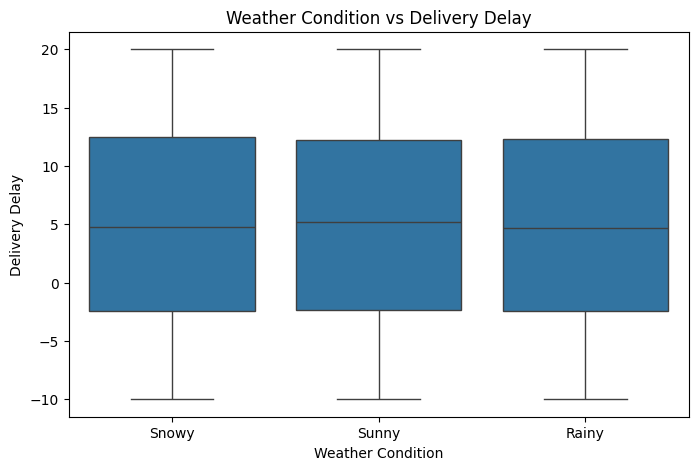

In [ ]:
#Weather Condition vs Delivery Delay
plt.figure(figsize=(8,5))
sns.boxplot(x='weather_condition', y='delivery_delay', data=df)

plt.title('Weather Condition vs Delivery Delay')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Delay')
plt.show()

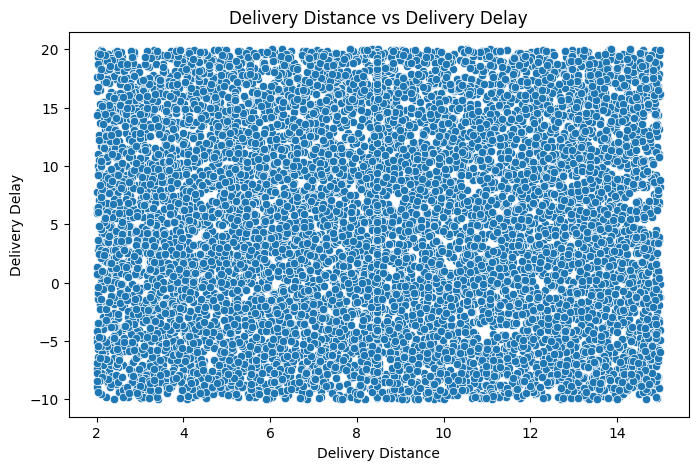

In [ ]:
#Delivery Distance vs Delivery Delay
plt.figure(figsize=(8,5))
sns.scatterplot(x='delivery_distance', y='delivery_delay', data=df)

plt.title('Delivery Distance vs Delivery Delay')
plt.xlabel('Delivery Distance')
plt.ylabel('Delivery Delay')
plt.show()

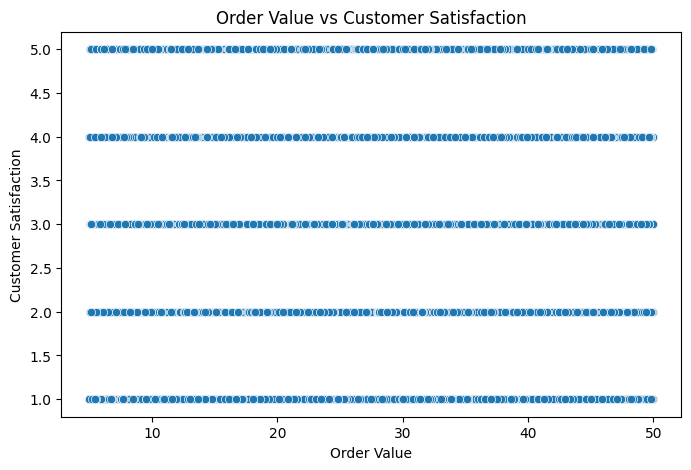

In [ ]:
#Order Value vs Customer Satisfaction
plt.figure(figsize=(8,5))
sns.scatterplot(x='order_value', y='customer_satisfaction', data=df)

plt.title('Order Value vs Customer Satisfaction')
plt.xlabel('Order Value')
plt.ylabel('Customer Satisfaction')
plt.show()

# Multivariate Analysis

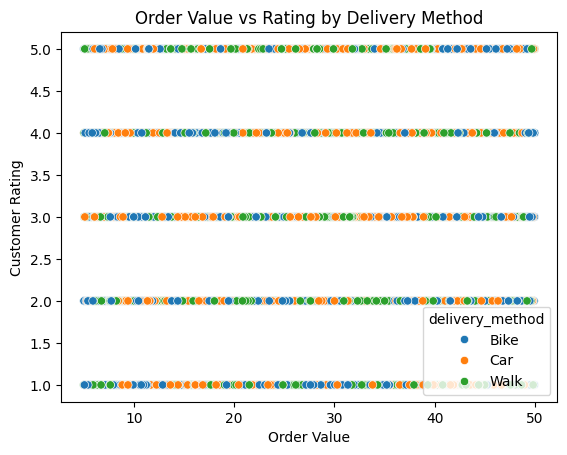

In [ ]:
#Order Value, Rating and Delivery Method
sns.scatterplot(
    x='order_value',
    y='customer_rating',
    hue='delivery_method',
    data=df
)

plt.title('Order Value vs Rating by Delivery Method')
plt.xlabel('Order Value')
plt.ylabel('Customer Rating')
plt.show()

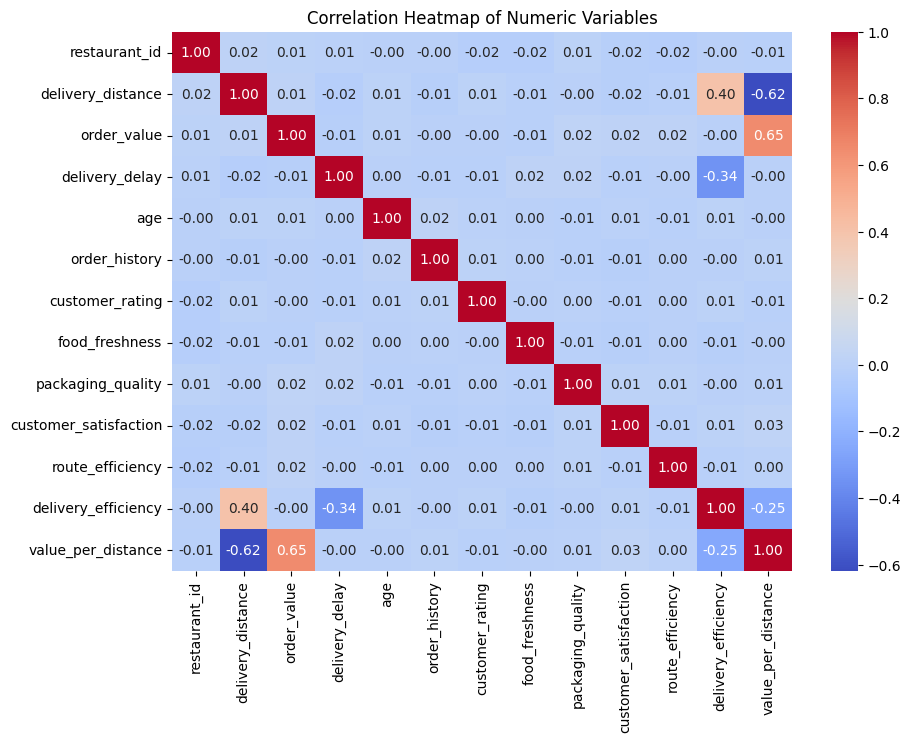

In [ ]:
#Correlation Heatmap of Numeric Variables
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [ ]:
# Traffic effect
print(df.groupby('traffic_condition')['delivery_delay'].mean())

# Weather effect
print(df.groupby('weather_condition')['delivery_delay'].mean())

# Delivery method effect
print(df.groupby('delivery_method')['delivery_delay'].mean())

# Customer satisfaction
print((df.groupby('customer_rating')['customer_satisfaction'].mean()))

traffic_condition
High      4.980852
Low       5.051725
Medium    4.824349
Name: delivery_delay, dtype: float64
weather_condition
Rainy    4.872745
Snowy    4.950746
Sunny    5.032926
Name: delivery_delay, dtype: float64
delivery_method
Bike    4.951679
Car     5.213558
Walk    4.701865
Name: delivery_delay, dtype: float64
customer_rating
1    2.997961
2    2.985090
3    2.975814
4    2.944917
5    2.978261
Name: customer_satisfaction, dtype: float64


In [ ]:
# Create target variable
median_delay = df['delivery_delay'].median()

df['delay_status'] = (
    df['delivery_delay'] > median_delay
).astype(int)

print(df['delay_status'].value_counts())

delay_status
0    10006
1     9994
Name: count, dtype: int64


In [ ]:
# Select input features
features = [
    'delivery_distance',
    'order_value',
    'age',
    'order_history',
    'food_freshness',
    'packaging_quality'
]

X = df[features]
y = df['delay_status']

In [ ]:
df[features].dtypes
df[features].isnull().sum()

,0
delivery_distance,0
order_value,0
age,0
order_history,0
food_freshness,0
packaging_quality,0


In [ ]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Training

In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Predictions & final insights

In [ ]:
#predictions
y_pred = model.predict(X_test)

In [ ]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.89075
Accuracy Percentage: 89.075 %


# Conclusion

The project analyzes food delivery data and finds useful patterns in orders and deliveries. It also uses machine learning to classify delivery delays.